In [71]:
import numpy as np 
import pickle 
import h5py
from scipy import stats
from tqdm.auto import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
import pandas as pd

%matplotlib inline 
import matplotlib.pyplot as plt
import seaborn as sns

# Plot correlations of model activations for stage of selection analysis 



path = "binaural_model_attn_stage_reps/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_model_activations_0dB_w_cues_and_corrs_v3.h5"

In [35]:
h5_dir = Path("binaural_model_attn_stage_reps")
model = "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned"
h5_path = h5_dir / f"{model}/{model}_model_activations_0dB_w_cues_and_corrs_v3.h5"

In [101]:
acts = h5py.File(h5_path, 'r')
print(acts.keys())
layer_names = sorted(set([key.split("_fg")[0] for key in acts.keys() if "fg" in key])) # set to remove duplicates 
print(layer_names)

dfs = []
for layer in layer_names:
    # get all keys that have _corr as suffix
    data_dict = {'fg_corrs':acts[f"{layer}_fg_mixture_corr"][:, 0],
                 'bg_corrs':acts[f"{layer}_bg_mixture_corr"][:, 0],
                 'fg_cos':acts[f"{layer}_fg_mixture_cos"][:],
                 'bg_cos':acts[f"{layer}_bg_mixture_cos"][:],
                 'layer': [layer]*len(acts[f"{layer}_fg_mixture_corr"])}
    if layer != 'cochleagram':
        data_dict['fg_no_cue_corrs'] = acts[f"{layer}_fg_mixture_corr_no_cue"][:, 0]
        data_dict['bg_no_cue_corrs'] = acts[f"{layer}_bg_mixture_corr_no_cue"][:, 0]
        data_dict['fg_no_cue_cos'] = acts[f"{layer}_fg_mixture_cos_no_cue"][:]
        data_dict['bg_no_cue_cos'] = acts[f"{layer}_bg_mixture_cos_no_cue"][:]
    if layer != 'relufc':
        data_dict['cue_corrs'] = acts[f"{layer}_cue_mixture_corr"][:, 0]
        data_dict['cue_cos'] = acts[f"{layer}_cue_mixture_cos"][:]

    df = pd.DataFrame(data_dict)
    dfs.append(df)
act_results  = pd.concat(dfs)
acts.close()

# where layer if cochleagram, set no cue corr and cos to with cue corr and cos
act_results.loc[act_results.layer == 'cochleagram', 'fg_no_cue_corrs'] = act_results.loc[act_results.layer == 'cochleagram', 'fg_corrs']
act_results.loc[act_results.layer == 'cochleagram', 'bg_no_cue_corrs'] = act_results.loc[act_results.layer == 'cochleagram', 'bg_corrs']
act_results.loc[act_results.layer == 'cochleagram', 'fg_no_cue_cos'] = act_results.loc[act_results.layer == 'cochleagram', 'fg_cos']
act_results.loc[act_results.layer == 'cochleagram', 'bg_no_cue_cos'] = act_results.loc[act_results.layer == 'cochleagram', 'bg_cos']
act_results['layer'] = act_results['layer'].str.replace('_block_', '')



act_corrs = pd.melt(act_results[[col for col in act_results.columns if 'cos' not in col]], id_vars =['layer'], value_vars=['cue_corrs', 'fg_corrs', 'bg_corrs', 'fg_no_cue_corrs', 'bg_no_cue_corrs'], var_name='Stream',
                            value_name="Pearson's r")
act_cos = pd.melt(act_results[[col for col in act_results.columns if 'corr' not in col]], id_vars =['layer'], value_vars=['cue_cos', 'fg_cos', 'bg_cos', 'fg_no_cue_cos', 'bg_no_cue_cos'], var_name='Stream',
                            value_name="Cosine similarity")

# merge 


act_corrs['Stream'].replace('cue_corrs','corr(cue, mixture)',inplace=True)
act_corrs['Stream'].replace('fg_corrs','corr($target_{cued}$, mixture)',inplace=True)
act_corrs['Stream'].replace('bg_corrs','corr($distractor_{cued}$, mixture)',inplace=True)
act_corrs['Stream'].replace('fg_no_cue_corrs','corr($target_{uncued}$, mixture)',inplace=True)
act_corrs['Stream'].replace('bg_no_cue_corrs','corr($distractor_{uncued}$, mixture)',inplace=True)

# same as above but cos instead of corrs 
act_cos['Stream'].replace('cue_corrs','cos(cue, mixture)',inplace=True)
act_cos['Stream'].replace('fg_cos', 'cos($target_{cued}$, mixture)', inplace=True)
act_cos['Stream'].replace('bg_cos', 'cos($distractor_{cued}$, mixture)', inplace=True)
act_cos['Stream'].replace('fg_no_cue_cos', 'cos($target_{uncued}$, mixture)', inplace=True)
act_cos['Stream'].replace('bg_no_cue_cos', 'cos($distractor_{uncued}$, mixture)', inplace=True)



<KeysViewHDF5 ['cochleagram_bg', 'cochleagram_bg_mixture_corr', 'cochleagram_bg_mixture_cos', 'cochleagram_cue', 'cochleagram_cue_mixture_corr', 'cochleagram_cue_mixture_cos', 'cochleagram_fg', 'cochleagram_fg_mixture_corr', 'cochleagram_fg_mixture_cos', 'cochleagram_mixture', 'conv_block_0_bg', 'conv_block_0_bg_mixture_corr', 'conv_block_0_bg_mixture_corr_no_cue', 'conv_block_0_bg_mixture_cos', 'conv_block_0_bg_mixture_cos_no_cue', 'conv_block_0_bg_no_cue', 'conv_block_0_cue', 'conv_block_0_cue_mixture_corr', 'conv_block_0_cue_mixture_cos', 'conv_block_0_fg', 'conv_block_0_fg_mixture_corr', 'conv_block_0_fg_mixture_corr_no_cue', 'conv_block_0_fg_mixture_cos', 'conv_block_0_fg_mixture_cos_no_cue', 'conv_block_0_fg_no_cue', 'conv_block_0_mixture', 'conv_block_0_mixture_no_cue', 'conv_block_1_bg', 'conv_block_1_bg_mixture_corr', 'conv_block_1_bg_mixture_corr_no_cue', 'conv_block_1_bg_mixture_cos', 'conv_block_1_bg_mixture_cos_no_cue', 'conv_block_1_bg_no_cue', 'conv_block_1_cue', 'conv_b

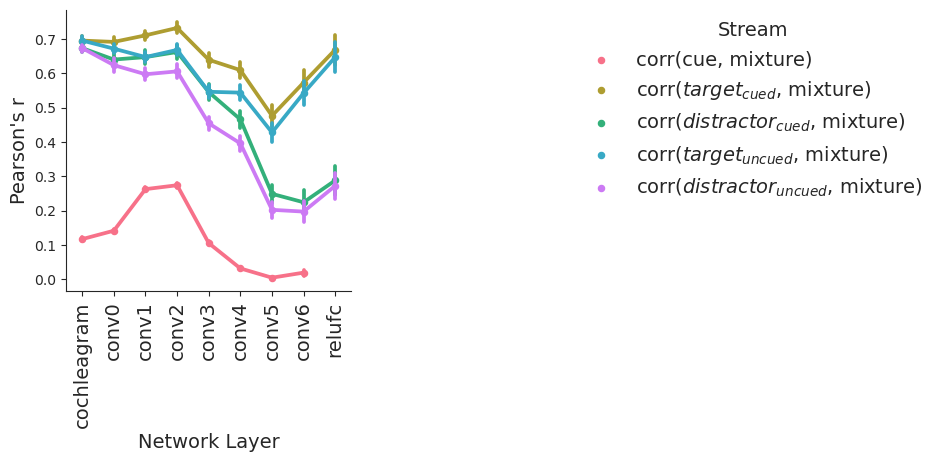

In [102]:
sns.set_style('ticks')
# to_plot = act_corrs[act_corrs['Stream'].str.contains('uncued')]
order = sorted(act_corrs.layer.unique())

p = sns.catplot(kind='point',data=act_corrs, x='layer', y="Pearson's r", order=order,
              hue = 'Stream', palette='husl', 
              height=4, aspect=1, markers='.',
              errorbar=('se', 2), seed=1)
fontsize=14

# plt.title("Speech + Noise Model \nMixture activations more correlated with\n target activations at later layers");
# g.set_axis_labels("", "Prop. Contour Correct")

p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
# set y limit to 0,1
# p.set(ylim=(0,1))

p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
sns.move_legend(p,
                loc="center right", bbox_to_anchor=(1.5, .6),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
# p.fig.suptitle("Full activations", size=fontsize)


Text(0.5, 0.98, 'Full activations')

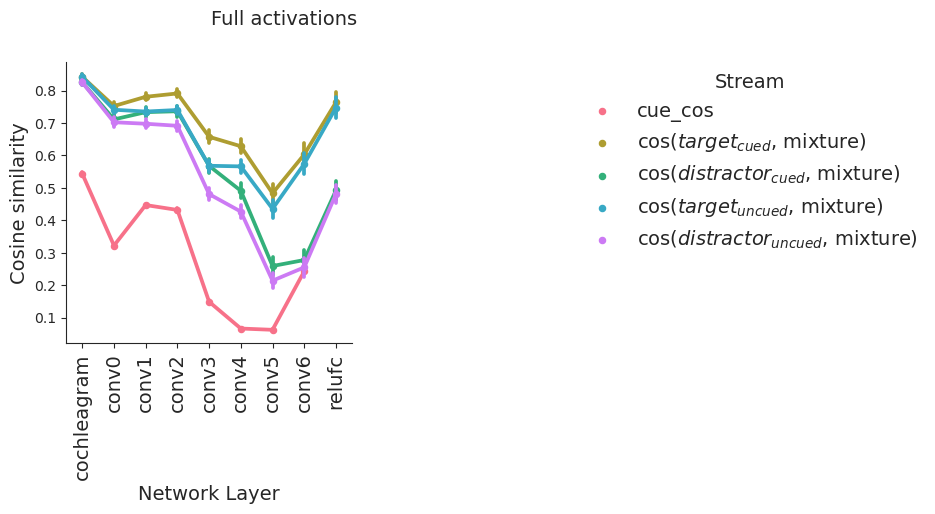

In [103]:
sns.set_style('ticks')
# to_plot = act_corrs[act_cos['Stream'].str.contains('uncued')]
order = sorted(act_cos.layer.unique())

p = sns.catplot(kind='point',data=act_cos, x='layer', y="Cosine similarity", order=order,
              hue = 'Stream', palette='husl', 
              height=4, aspect=1, markers='.',
              errorbar=('se', 2), seed=1)
fontsize=14

# plt.title("Speech + Noise Model \nMixture activations more correlated with\n target activations at later layers");
# g.set_axis_labels("", "Prop. Contour Correct")

p.set_axis_labels("Network Layer", "Cosine similarity", size=fontsize)
# set y limit to 0,1
# p.set(ylim=(0,1))

p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
sns.move_legend(p,
                loc="center right", bbox_to_anchor=(1.5, .6),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("Full activations", size=fontsize)


## Old correlation development

In [22]:
def torch_pearsons_r(x,y):
    '''Calculates pearsons r between x and y.
       Assumes x and y are both N dimensional tensors.
    ''' 
    x_demean = x - x.mean(dim=0)
    y_demean = y - y.mean(dim=0)
    r = torch.sum(x_demean * y_demean) / (torch.sqrt(torch.sum(x_demean ** 2)) * torch.sqrt(torch.sum(y_demean ** 2)))
    return r 

In [3]:
# Get model activation files 
from pathlib import Path 

out_dir = Path('binaural_model_attn_stage_reps/')
# paths = list(out_dir.glob('*model_activations_0dB.h5'))
# path  = Path("binaural_model_attn_stage_reps/word_task_half_co_loc_v08_gender_bal_4M_orig_model_activations_0dB_compare_with_attn.h5")
path  = out_dir / "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_model_activations_0dB_w_cues_v3.h5"
layer_shape_dict = pickle.load(open('binaural_model_attn_stage_reps/word_task_half_co_loc_v07/word_task_half_co_loc_v07_layer_shape_dict.pkl', 'rb'))
model_out_dir = out_dir / 'word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned'

In [4]:
# corrs  = pickle.load(open("binaural_model_attn_stage_reps/word_task_half_co_loc_v07/word_task_half_co_loc_v07_model_activations_0dB_w_cues_v3_corrs.pkl", 'rb'))

In [5]:
def get_frames_per_sec(n_frames, dur):
    return n_frames/dur

def get_frames_for_context(context_len, rate):
    return int(context_len*rate)

# given number of time frames, total signal length and desired context, get frames that correspond to that context centered on the middle of the signal 
def get_context_frames(n_frames, dur, context_len):
    rate = get_frames_per_sec(n_frames, dur)
    context_frames = get_frames_for_context(context_len, rate)
    return n_frames//2 - context_frames//2, n_frames//2 + context_frames//2 + 1 

# sanity check outputs 
print(get_frames_per_sec(50, 2))
print(get_frames_for_context(.0010, 1000))
print(get_context_frames(63, 2, 0.5))

25.0
1
(24, 39)


In [7]:
acts =  h5py.File(path, 'r')
print(acts.keys())
layer_names = set([key.split("_mixture")[0] for key in acts.keys() if "mixture" in key]) # set to remove duplicates 
print(layer_names)

# get eg act for speed test 

eg_act = acts["cochleagram_mixture"][1]

acts.close()


<KeysViewHDF5 ['cochleagram_bg', 'cochleagram_cue', 'cochleagram_fg', 'cochleagram_mixture', 'conv_block_0_bg', 'conv_block_0_bg_no_cue', 'conv_block_0_cue', 'conv_block_0_fg', 'conv_block_0_fg_no_cue', 'conv_block_0_mixture', 'conv_block_0_mixture_no_cue', 'conv_block_1_bg', 'conv_block_1_bg_no_cue', 'conv_block_1_cue', 'conv_block_1_fg', 'conv_block_1_fg_no_cue', 'conv_block_1_mixture', 'conv_block_1_mixture_no_cue', 'conv_block_2_bg', 'conv_block_2_bg_no_cue', 'conv_block_2_cue', 'conv_block_2_fg', 'conv_block_2_fg_no_cue', 'conv_block_2_mixture', 'conv_block_2_mixture_no_cue', 'conv_block_3_bg', 'conv_block_3_bg_no_cue', 'conv_block_3_cue', 'conv_block_3_fg', 'conv_block_3_fg_no_cue', 'conv_block_3_mixture', 'conv_block_3_mixture_no_cue', 'conv_block_4_bg', 'conv_block_4_bg_no_cue', 'conv_block_4_cue', 'conv_block_4_fg', 'conv_block_4_fg_no_cue', 'conv_block_4_mixture', 'conv_block_4_mixture_no_cue', 'conv_block_5_bg', 'conv_block_5_bg_no_cue', 'conv_block_5_cue', 'conv_block_5_fg'

In [17]:
## speed test corr using pearon r
import torch
import time

np_outs = np.zeros(100)
with h5py.File(path, 'r') as acts:
    start = time.time()
    for i in range(100):
        mix = acts["cochleagram_mixture"][i]
        fg = acts["cochleagram_fg"][i]
        np_outs[i] = pearsonr(fg, mix)[0]
    print(time.time() - start)


15.142704725265503


In [23]:
eg_torch = torch.from_numpy(eg_act)
torch_outs = np.zeros(100)

with h5py.File(path, 'r') as acts:
    start = time.time()
    for i in range(100):
        mix = torch.from_numpy(acts["cochleagram_mixture"][i])
        fg = torch.from_numpy(acts["cochleagram_fg"][i])
        torch_outs[i] = torch_pearsons_r(fg, mix).numpy()
    print(time.time() - start)


1.4990859031677246


### Should use manual implementation instead of scipy 

In [31]:
np.allclose(torch_outs, np_outs)

True

# Talker correlation by layer sanity check

#### Compare $\text{corr}(\text{source}_ {\text{cued}},\text{mixture}_ {\text{cued}})$ and $\text{corr}(\text{source}_ {\text{uncued}},\text{mixture}_ {\text{cued}})$ for target and distractor sources 

In [8]:


# with h5py.File(path, 'r') as acts:
#     print(acts.keys())
#     layer_names = set([key.split("_mixture")[0] for key in acts.keys() if "mixture" in key]) # set to remove duplicates 
#     print(layer_names)
#     corr_results = {}

#     out_name = f"{path.stem}_corrs_sanity_check.pkl"
#     # Save results as dict
#     out_name = model_out_dir / out_name
#     print(out_name)
#     N_acts = acts["cochleagram_mixture"].shape[0]

#     for layer in layer_names:
#         mixture_acts = acts[f"{layer}_mixture"][:]
#         target_acts = acts[f"{layer}_fg"][:]
#         bg_acts = acts[f"{layer}_bg"][:]

#         if layer == 'cochleagram':
#             fg_wo_cue_acts = None
#             bg_wo_cue_acts = None 
#         else:
#             fg_wo_cue_acts = acts[f"{layer}_fg_no_cue"][:]
#             bg_wo_cue_acts =  acts[f"{layer}_bg_no_cue"][:] 

#         corr_results[f"{layer}_fg"] = np.zeros((N_acts, 2), dtype=np.float32)
#         corr_results[f"{layer}_bg"] = np.zeros((N_acts, 2), dtype=np.float32)
#         if fg_wo_cue_acts is not None:
#             corr_results[f"{layer}_fg_no_cue"] = np.zeros((N_acts, 2), dtype=np.float32)
#             corr_results[f"{layer}_bg_no_cue"] = np.zeros((N_acts, 2), dtype=np.float32)
        
#         for i in tqdm(range(N_acts), desc=f"Getting correlations from {layer}", leave=False):
#             if i == 0:
#                 print(target_acts[1].shape)
#             corr_results[f"{layer}_fg"][i,:] = stats.pearsonr(target_acts[i], mixture_acts[i])
#             corr_results[f"{layer}_bg"][i,:] = stats.pearsonr(bg_acts[i], mixture_acts[i])
#             if fg_wo_cue_acts is not None:
#                 corr_results[f"{layer}_fg_no_cue"][i,:] = stats.pearsonr(fg_wo_cue_acts[i], mixture_acts[i])
#                 corr_results[f"{layer}_bg_no_cue"][i,:] = stats.pearsonr(bg_wo_cue_acts[i], mixture_acts[i])

        
#         # set type as float32
#         # for key in corr_results.keys():
#         #     if len(corr_results[key]) > 0:
#         #         corr_results[key] = np.array(corr_results[key], dtype=np.float32)
        
#     out_dict = dict(corr_results=corr_results)

#     with open(out_name ,'wb') as f:
#         pickle.dump(out_dict, f)


<KeysViewHDF5 ['cochleagram_bg', 'cochleagram_cue', 'cochleagram_fg', 'cochleagram_mixture', 'conv_block_0_bg', 'conv_block_0_bg_no_cue', 'conv_block_0_cue', 'conv_block_0_fg', 'conv_block_0_fg_no_cue', 'conv_block_0_mixture', 'conv_block_0_mixture_no_cue', 'conv_block_1_bg', 'conv_block_1_bg_no_cue', 'conv_block_1_cue', 'conv_block_1_fg', 'conv_block_1_fg_no_cue', 'conv_block_1_mixture', 'conv_block_1_mixture_no_cue', 'conv_block_2_bg', 'conv_block_2_bg_no_cue', 'conv_block_2_cue', 'conv_block_2_fg', 'conv_block_2_fg_no_cue', 'conv_block_2_mixture', 'conv_block_2_mixture_no_cue', 'conv_block_3_bg', 'conv_block_3_bg_no_cue', 'conv_block_3_cue', 'conv_block_3_fg', 'conv_block_3_fg_no_cue', 'conv_block_3_mixture', 'conv_block_3_mixture_no_cue', 'conv_block_4_bg', 'conv_block_4_bg_no_cue', 'conv_block_4_cue', 'conv_block_4_fg', 'conv_block_4_fg_no_cue', 'conv_block_4_mixture', 'conv_block_4_mixture_no_cue', 'conv_block_5_bg', 'conv_block_5_bg_no_cue', 'conv_block_5_cue', 'conv_block_5_fg'

Getting correlations from conv_block_3:   0%|          | 0/100 [00:00<?, ?it/s]

(1254400,)


Getting correlations from relufc:   0%|          | 0/100 [00:00<?, ?it/s]

(512,)


...

Getting correlations from conv_block_6:   0%|          | 0/100 [00:00<?, ?it/s]

(196608,)


Getting correlations from conv_block_0:   0%|          | 0/100 [00:00<?, ?it/s]

(24918816,)


KeyboardInterrupt: 

In [10]:
import h5py
import numpy as np
import pickle
from scipy.stats import pearsonr
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed

def compute_correlations_for_layer(layer_name, h5_file_path, out_dir):
    with h5py.File(h5_file_path, 'r') as acts:
        N_acts = acts["cochleagram_mixture"].shape[0]
        mixture_acts = acts[f"{layer_name}_mixture"]
        target_acts = acts[f"{layer_name}_fg"]
        bg_acts = acts[f"{layer_name}_bg"]
        
        if layer_name == 'cochleagram':
            fg_wo_cue_acts = None
            bg_wo_cue_acts = None
        else:
            fg_wo_cue_acts = acts[f"{layer_name}_fg_no_cue"]
            bg_wo_cue_acts = acts[f"{layer_name}_bg_no_cue"]
        
        corr_results = {
            f"{layer_name}_fg": np.zeros((N_acts, 2), dtype=np.float32),
            f"{layer_name}_bg": np.zeros((N_acts, 2), dtype=np.float32)
        }
        if fg_wo_cue_acts is not None:
            corr_results[f"{layer_name}_fg_no_cue"] = np.zeros((N_acts, 2), dtype=np.float32)
            corr_results[f"{layer_name}_bg_no_cue"] = np.zeros((N_acts, 2), dtype=np.float32)
        
        for i in range(N_acts):
            corr_results[f"{layer_name}_fg"][i, :] = pearsonr(target_acts[i], mixture_acts[i])
            corr_results[f"{layer_name}_bg"][i, :] = pearsonr(bg_acts[i], mixture_acts[i])
            if fg_wo_cue_acts is not None:
                corr_results[f"{layer_name}_fg_no_cue"][i, :] = pearsonr(fg_wo_cue_acts[i], mixture_acts[i])
                corr_results[f"{layer_name}_bg_no_cue"][i, :] = pearsonr(bg_wo_cue_acts[i], mixture_acts[i])
        
        out_dict = dict(corr_results=corr_results)
        out_name = out_dir / f"{layer_name}_corrs.pkl"
        with open(out_name, 'wb') as f:
            pickle.dump(out_dict, f)
        print(f"Saved correlations for {layer_name}")
        return corr_results


def compute_cosine_similarity_for_layer(layer_name, h5_file_path, out_dir):
    with h5py.File(h5_file_path, 'r') as acts:
        N_acts = acts["cochleagram_mixture"].shape[0]
        mixture_acts = acts[f"{layer_name}_mixture"]
        target_acts = acts[f"{layer_name}_fg"]
        bg_acts = acts[f"{layer_name}_bg"]
        
        if layer_name == 'cochleagram':
            fg_wo_cue_acts = None
            bg_wo_cue_acts = None
        else:
            fg_wo_cue_acts = acts[f"{layer_name}_fg_no_cue"]
            bg_wo_cue_acts = acts[f"{layer_name}_bg_no_cue"]
        
        corr_results = {
            f"{layer_name}_fg": np.zeros((N_acts, 1), dtype=np.float32),
            f"{layer_name}_bg": np.zeros((N_acts, 1), dtype=np.float32)
        }
        if fg_wo_cue_acts is not None:
            cos_results[f"{layer_name}_fg_no_cue"] = np.zeros((N_acts, 2), dtype=np.float32)
            cos_results[f"{layer_name}_bg_no_cue"] = np.zeros((N_acts, 2), dtype=np.float32)
        
        for i in range(N_acts):
            cos_results[f"{layer_name}_fg"][i, :] = cosine_similarity(target_acts[i].reshape(1,-1), mixture_acts[i].reshape(1,-1))
            cos_results[f"{layer_name}_bg"][i, :] = cosine_similarity(bg_acts[i].reshape(1,-1), mixture_acts[i].reshape(1,-1))
            if fg_wo_cue_acts is not None:
                cos_results[f"{layer_name}_fg_no_cue"][i, :] = cosine_similarity(fg_wo_cue_acts[i].reshape(1,-1), mixture_acts[i].reshape(1,-1))
                cos_results[f"{layer_name}_bg_no_cue"][i, :] = cosine_similarity(bg_wo_cue_acts[i].reshape(1,-1), mixture_acts[i].reshape(1,-1))
        
        out_dict = dict(cos_results=cos_results)
        out_name = out_dir / f"{layer_name}_cos_sim.pkl"
        with open(out_name, 'wb') as f:
            pickle.dump(out_dict, f)
        print(f"Saved cosine similarities for {layer_name}")
        return cos_results


def thread_worker(process_executor, layer, h5_file_path, out_dir):
    future = process_executor.submit(compute_correlations_for_layer, layer, h5_file_path, out_dir)
    corr_results = future.result() # Just for demo purposes
    return corr_results
    

with h5py.File(path, 'r') as acts:
    layer_names = set([key.split("_mixture")[0] for key in acts.keys() if "mixture" in key]) # set to remove duplicates 


with ProcessPoolExecutor() as process_executor:
    with ThreadPoolExecutor(10) as thread_executor:
        # Each input results in multiple threading jobs being created:
        futures = [
            thread_executor.submit(thread_worker, process_executor, layer, path, model_out_dir)
                for layer in layer_names
        ]
        results = [future.result() for future in as_completed(futures)]

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/stats/stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())


#### Same but measuring cosine similarity

In [44]:
from sklearn.metrics.pairwise import cosine_similarity


with h5py.File(path, 'r') as acts:
    print(acts.keys())
    layer_names = set([key.split("_mixture")[0] for key in acts.keys() if "mixture" in key]) # set to remove duplicates 
    print(layer_names)
    cos_results_full = {}

    out_name = f"{path.stem}_cos_similarity.pkl"
    # Save results as dict
    out_name = model_out_dir / out_name
    print(out_name)
    N_acts = acts["cochleagram_mixture"].shape[0]

    for layer in layer_names:
        mixture_acts = acts[f"{layer}_mixture"]
        target_acts = acts[f"{layer}_fg"]
        bg_acts = acts[f"{layer}_bg"]

        if layer == 'cochleagram':
            fg_wo_cue_acts = None
            bg_wo_cue_acts = None 
        else:
            fg_wo_cue_acts = acts[f"{layer}_fg_no_cue"]
            bg_wo_cue_acts =  acts[f"{layer}_bg_no_cue"] 
        print(layer)
        cos_results_full[f"{layer}_fg"] = []
        cos_results_full[f"{layer}_bg"] = []
        if fg_wo_cue_acts is not None:
            cos_results_full[f"{layer}_fg_no_cue"] = []
            cos_results_full[f"{layer}_bg_no_cue"] = []
        
        for i in tqdm(range(N_acts), desc=f"Getting correlations from {layer}", leave=False):
            cos_results_full[f"{layer}_fg"].append(cosine_similarity(target_acts[i].reshape(1,-1), mixture_acts[i].reshape(1,-1)))
            cos_results_full[f"{layer}_bg"].append(cosine_similarity(bg_acts[i].reshape(1,-1), mixture_acts[i].reshape(1,-1)))
            if fg_wo_cue_acts is not None:
                cos_results_full[f"{layer}_fg_no_cue"].append(cosine_similarity(fg_wo_cue_acts[i].reshape(1,-1), mixture_acts[i].reshape(1,-1)))
                cos_results_full[f"{layer}_bg_no_cue"].append(cosine_similarity(bg_wo_cue_acts[i].reshape(1,-1), mixture_acts[i].reshape(1,-1)))

        
        # set type as float32
        for key in cos_results_full.keys():
            if len(cos_results_full[key]) > 0:
                cos_results_full[key] = np.array(cos_results_full[key], dtype=np.float32)
        
    out_dict = dict(cos_results=cos_results_full)

    with open(out_name ,'wb') as f:
        pickle.dump(out_dict, f)


<KeysViewHDF5 ['cochleagram_bg', 'cochleagram_cue', 'cochleagram_fg', 'cochleagram_mixture', 'conv_block_0_bg', 'conv_block_0_bg_no_cue', 'conv_block_0_cue', 'conv_block_0_fg', 'conv_block_0_fg_no_cue', 'conv_block_0_mixture', 'conv_block_0_mixture_no_cue', 'conv_block_1_bg', 'conv_block_1_bg_no_cue', 'conv_block_1_cue', 'conv_block_1_fg', 'conv_block_1_fg_no_cue', 'conv_block_1_mixture', 'conv_block_1_mixture_no_cue', 'conv_block_2_bg', 'conv_block_2_bg_no_cue', 'conv_block_2_cue', 'conv_block_2_fg', 'conv_block_2_fg_no_cue', 'conv_block_2_mixture', 'conv_block_2_mixture_no_cue', 'conv_block_3_bg', 'conv_block_3_bg_no_cue', 'conv_block_3_cue', 'conv_block_3_fg', 'conv_block_3_fg_no_cue', 'conv_block_3_mixture', 'conv_block_3_mixture_no_cue', 'conv_block_4_bg', 'conv_block_4_bg_no_cue', 'conv_block_4_cue', 'conv_block_4_fg', 'conv_block_4_fg_no_cue', 'conv_block_4_mixture', 'conv_block_4_mixture_no_cue', 'conv_block_5_bg', 'conv_block_5_bg_no_cue', 'conv_block_5_cue', 'conv_block_5_fg'

Getting correlations from conv_block_5:   0%|          | 0/100 [00:00<?, ?it/s]

cochleagram


Getting correlations from cochleagram:   0%|          | 0/100 [00:00<?, ?it/s]

conv_block_1


...

Getting correlations from relufc:   0%|          | 0/100 [00:00<?, ?it/s]

conv_block_3


Getting correlations from conv_block_3:   0%|          | 0/100 [00:00<?, ?it/s]

conv_block_4


Getting correlations from conv_block_4:   0%|          | 0/100 [00:00<?, ?it/s]

#### Get corrs for middle and edges of signal

In [63]:

TOTAL_SIGNAL_LEN = 2
CONTEXT_LEN = 0.100

with h5py.File(path, 'r') as acts:
    print(acts.keys())
    layer_names = set([key.split("_mixture")[0] for key in acts.keys() if "mixture" in key]) # set to remove duplicates 
    print(layer_names)
    corr_results = {}

    out_name = f"{path.stem}_corrs_middle_frames.pkl"
    # Save results as dict
    out_name = model_out_dir / out_name
    print(out_name)
    N_acts = acts["cochleagram_mixture"].shape[0]

    for layer in layer_names:
        mixture_acts = acts[f"{layer}_mixture"]
        target_acts = acts[f"{layer}_fg"]
        bg_acts = acts[f"{layer}_bg"]

        # get layer shape
        layer_shape = layer_shape_dict[layer]
        middle_onset, middle_offset = get_context_frames(layer_shape[2], TOTAL_SIGNAL_LEN, CONTEXT_LEN)
        middle_frames = slice(middle_onset, middle_offset)

        if layer == 'cochleagram':
            fg_wo_cue_acts = None
            bg_wo_cue_acts = None 
        else:
            fg_wo_cue_acts = acts[f"{layer}_fg_no_cue"]
            bg_wo_cue_acts =  acts[f"{layer}_bg_no_cue"] 
        print(layer)
        corr_results[f"{layer}_fg"] = []
        corr_results[f"{layer}_bg"] = []
        if fg_wo_cue_acts is not None:
            corr_results[f"{layer}_fg_no_cue"] = []
            corr_results[f"{layer}_bg_no_cue"] = []
        
        for i in tqdm(range(N_acts), desc=f"Getting correlations from {layer}", leave=False):
            corr_results[f"{layer}_fg"].append(stats.pearsonr(target_acts[i].reshape(layer_shape)[...,middle_frames].flatten(), mixture_acts[i].reshape(layer_shape)[...,middle_frames].flatten()))
            corr_results[f"{layer}_bg"].append(stats.pearsonr(bg_acts[i].reshape(layer_shape)[...,middle_frames].flatten(), mixture_acts[i].reshape(layer_shape)[...,middle_frames].flatten()))
            if fg_wo_cue_acts is not None:
                corr_results[f"{layer}_fg_no_cue"].append(stats.pearsonr(fg_wo_cue_acts[i].reshape(layer_shape)[...,middle_frames].flatten(), mixture_acts[i].reshape(layer_shape)[...,middle_frames].flatten()))
                corr_results[f"{layer}_bg_no_cue"].append(stats.pearsonr(bg_wo_cue_acts[i].reshape(layer_shape)[...,middle_frames].flatten(), mixture_acts[i].reshape(layer_shape)[...,middle_frames].flatten()))

        
        # set type as float32
        for key in corr_results.keys():
            if len(corr_results[key]) > 0:
                corr_results[key] = np.array(corr_results[key], dtype=np.float32)
        
    out_dict = dict(corr_results=corr_results)

    with open(out_name ,'wb') as f:
        pickle.dump(out_dict, f)


<KeysViewHDF5 ['cochleagram_bg', 'cochleagram_cue', 'cochleagram_fg', 'cochleagram_mixture', 'conv_block_0_bg', 'conv_block_0_bg_no_cue', 'conv_block_0_cue', 'conv_block_0_fg', 'conv_block_0_fg_no_cue', 'conv_block_0_mixture', 'conv_block_0_mixture_no_cue', 'conv_block_1_bg', 'conv_block_1_bg_no_cue', 'conv_block_1_cue', 'conv_block_1_fg', 'conv_block_1_fg_no_cue', 'conv_block_1_mixture', 'conv_block_1_mixture_no_cue', 'conv_block_2_bg', 'conv_block_2_bg_no_cue', 'conv_block_2_cue', 'conv_block_2_fg', 'conv_block_2_fg_no_cue', 'conv_block_2_mixture', 'conv_block_2_mixture_no_cue', 'conv_block_3_bg', 'conv_block_3_bg_no_cue', 'conv_block_3_cue', 'conv_block_3_fg', 'conv_block_3_fg_no_cue', 'conv_block_3_mixture', 'conv_block_3_mixture_no_cue', 'conv_block_4_bg', 'conv_block_4_bg_no_cue', 'conv_block_4_cue', 'conv_block_4_fg', 'conv_block_4_fg_no_cue', 'conv_block_4_mixture', 'conv_block_4_mixture_no_cue', 'conv_block_5_bg', 'conv_block_5_bg_no_cue', 'conv_block_5_cue', 'conv_block_5_fg'

Getting correlations from conv_block_4:   0%|          | 0/100 [00:00<?, ?it/s]

conv_block_5


Getting correlations from conv_block_5:   0%|          | 0/100 [00:00<?, ?it/s]

cochleagram


...

conv_block_1


Getting correlations from conv_block_1:   0%|          | 0/100 [00:00<?, ?it/s]

conv_block_3


Getting correlations from conv_block_3:   0%|          | 0/100 [00:00<?, ?it/s]

IndexError: tuple index out of range

In [67]:
from sklearn.metrics.pairwise import cosine_similarity

TOTAL_SIGNAL_LEN = 2
CONTEXT_LEN = 0.100

with h5py.File(path, 'r') as acts:
    print(acts.keys())
    layer_names = set([key.split("_mixture")[0] for key in acts.keys() if "mixture" in key]) # set to remove duplicates 
    print(layer_names)
    cos_results = {}

    out_name = f"{path.stem}_corrs_middle_frames.pkl"
    # Save results as dict
    out_name = model_out_dir / out_name
    print(out_name)
    N_acts = acts["cochleagram_mixture"].shape[0]

    for layer in layer_names:
        mixture_acts = acts[f"{layer}_mixture"]
        target_acts = acts[f"{layer}_fg"]
        bg_acts = acts[f"{layer}_bg"]

        # get layer shape
        layer_shape = layer_shape_dict[layer]
        middle_onset, middle_offset = get_context_frames(layer_shape[2], TOTAL_SIGNAL_LEN, CONTEXT_LEN)
        middle_frames = slice(middle_onset, middle_offset)

        if layer == 'cochleagram':
            fg_wo_cue_acts = None
            bg_wo_cue_acts = None 
        else:
            fg_wo_cue_acts = acts[f"{layer}_fg_no_cue"]
            bg_wo_cue_acts =  acts[f"{layer}_bg_no_cue"] 
        print(layer)
        cos_results[f"{layer}_fg"] = []
        cos_results[f"{layer}_bg"] = []
        if fg_wo_cue_acts is not None:
            cos_results[f"{layer}_fg_no_cue"] = []
            cos_results[f"{layer}_bg_no_cue"] = []
        
        for i in tqdm(range(N_acts), desc=f"Getting correlations from {layer}", leave=False):
            cos_results[f"{layer}_fg"].append(cosine_similarity(target_acts[i].reshape(layer_shape)[...,middle_frames].reshape(1,-1), mixture_acts[i].reshape(layer_shape)[...,middle_frames].reshape(1,-1)).squeeze())
            cos_results[f"{layer}_bg"].append(cosine_similarity(bg_acts[i].reshape(layer_shape)[...,middle_frames].reshape(1,-1), mixture_acts[i].reshape(layer_shape)[...,middle_frames].reshape(1,-1)).squeeze())
            if fg_wo_cue_acts is not None:
                cos_results[f"{layer}_fg_no_cue"].append(cosine_similarity(fg_wo_cue_acts[i].reshape(layer_shape)[...,middle_frames].reshape(1,-1), mixture_acts[i].reshape(layer_shape)[...,middle_frames].reshape(1,-1)).squeeze())
                cos_results[f"{layer}_bg_no_cue"].append(cosine_similarity(bg_wo_cue_acts[i].reshape(layer_shape)[...,middle_frames].reshape(1,-1), mixture_acts[i].reshape(layer_shape)[...,middle_frames].reshape(1,-1)).squeeze())

        
        # set type as float32
        for key in cos_results.keys():
            if len(cos_results[key]) > 0:
                cos_results[key] = np.array(cos_results[key], dtype=np.float32)
        
    out_dict = dict(cos_results=cos_results)

    with open(out_name ,'wb') as f:
        pickle.dump(out_dict, f)


<KeysViewHDF5 ['cochleagram_bg', 'cochleagram_cue', 'cochleagram_fg', 'cochleagram_mixture', 'conv_block_0_bg', 'conv_block_0_bg_no_cue', 'conv_block_0_cue', 'conv_block_0_fg', 'conv_block_0_fg_no_cue', 'conv_block_0_mixture', 'conv_block_0_mixture_no_cue', 'conv_block_1_bg', 'conv_block_1_bg_no_cue', 'conv_block_1_cue', 'conv_block_1_fg', 'conv_block_1_fg_no_cue', 'conv_block_1_mixture', 'conv_block_1_mixture_no_cue', 'conv_block_2_bg', 'conv_block_2_bg_no_cue', 'conv_block_2_cue', 'conv_block_2_fg', 'conv_block_2_fg_no_cue', 'conv_block_2_mixture', 'conv_block_2_mixture_no_cue', 'conv_block_3_bg', 'conv_block_3_bg_no_cue', 'conv_block_3_cue', 'conv_block_3_fg', 'conv_block_3_fg_no_cue', 'conv_block_3_mixture', 'conv_block_3_mixture_no_cue', 'conv_block_4_bg', 'conv_block_4_bg_no_cue', 'conv_block_4_cue', 'conv_block_4_fg', 'conv_block_4_fg_no_cue', 'conv_block_4_mixture', 'conv_block_4_mixture_no_cue', 'conv_block_5_bg', 'conv_block_5_bg_no_cue', 'conv_block_5_cue', 'conv_block_5_fg'

Getting correlations from conv_block_4:   0%|          | 0/100 [00:00<?, ?it/s]

conv_block_5


Getting correlations from conv_block_5:   0%|          | 0/100 [00:00<?, ?it/s]

cochleagram


...

conv_block_1


Getting correlations from conv_block_1:   0%|          | 0/100 [00:00<?, ?it/s]

conv_block_3


Getting correlations from conv_block_3:   0%|          | 0/100 [00:00<?, ?it/s]

IndexError: tuple index out of range

## Plot Results

In [13]:
## Make layer plot 

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import pickle 
import pandas as pd


In [9]:
out_name = f"{path.stem}_cos_similarity.pkl"
# Save results as dict
out_name = out_dir / out_name

In [10]:
out_name

PosixPath('binaural_model_attn_stage_reps/word_task_half_co_loc_v07_model_activations_0dB_w_cues_v3_cos_similarity.pkl')

In [17]:
[res.keys() for res in results]

[dict_keys(['relufc_fg', 'relufc_bg', 'relufc_fg_no_cue', 'relufc_bg_no_cue']),
 dict_keys(['conv_block_6_fg', 'conv_block_6_bg', 'conv_block_6_fg_no_cue', 'conv_block_6_bg_no_cue']),
 dict_keys(['conv_block_5_fg', 'conv_block_5_bg', 'conv_block_5_fg_no_cue', 'conv_block_5_bg_no_cue']),
 dict_keys(['conv_block_4_fg', 'conv_block_4_bg', 'conv_block_4_fg_no_cue', 'conv_block_4_bg_no_cue']),
 dict_keys(['cochleagram_fg', 'cochleagram_bg']),
 dict_keys(['conv_block_3_fg', 'conv_block_3_bg', 'conv_block_3_fg_no_cue', 'conv_block_3_bg_no_cue']),
 dict_keys(['conv_block_2_fg', 'conv_block_2_bg', 'conv_block_2_fg_no_cue', 'conv_block_2_bg_no_cue']),
 dict_keys(['conv_block_1_fg', 'conv_block_1_bg', 'conv_block_1_fg_no_cue', 'conv_block_1_bg_no_cue']),
 dict_keys(['conv_block_0_fg', 'conv_block_0_bg', 'conv_block_0_fg_no_cue', 'conv_block_0_bg_no_cue'])]

,layer,Stream,Pearson's r
0,relufc,target with cue,0.775964
1,relufc,target with cue,0.807663
2,relufc,target with cue,0.249503
3,relufc,target with cue,0.612266
4,relufc,target with cue,0.409129
...,...,...,...
3595,conv0,distractor without cue,0.616642
3596,conv0,distractor without cue,0.687497
3597,conv0,distractor without cue,0.626835
3598,conv0,distractor without cue,0.646087


In [31]:
list(model_out_dir.glob('*corrs.pkl'))

[PosixPath('binaural_model_attn_stage_reps/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned/cochleagram_corrs.pkl'),
 PosixPath('binaural_model_attn_stage_reps/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned/conv_block_0_corrs.pkl'),
 PosixPath('binaural_model_attn_stage_reps/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned/conv_block_1_corrs.pkl'),
 PosixPath('binaural_model_attn_stage_reps/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned/conv_block_2_corrs.pkl'),
 PosixPath('binaural_model_attn_stage_reps/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned/conv_block_3_corrs.pkl'),
 PosixPath('binaural_model_attn_stage_reps/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned/conv_block_4_corrs.pkl'),
 PosixPath('binaural_model_attn_stage_reps/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned/conv_block_5_corrs.pkl'),
 PosixPath('binaural_model_attn_stage_reps/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned/conv_block_6_corrs.

In [41]:
# put results into dataframe
# put into df for easy plotting:

# load results

# # out_name = out_dir / f"{paths[0].stem}_corrs.pkl"
# with open("binaural_model_attn_stage_reps/word_task_half_co_loc_v07_model_activations_0dB_w_cues_v3_corrs_sanity_check.pkl", 'rb') as f:
#     results = pickle.load(f)
pkl_fns = list(model_out_dir.glob('*corrs.pkl'))
saved_results = []

for pkl_fn in pkl_fns:
    with open(pkl_fn, 'rb') as f:
        saved_results.append(pickle.load(f)['corr_results'])

# fg_corr_results = {key.replace('_fg', ''): val[:,0] for key,val in results.items() if '_fg' in key and 'no_cue' not in key}
# bg_corr_results = {key.replace('_bg', ''): val[:,0] for key,val in results.items() if '_bg' in key and 'no_cue' not in key}

# fg_no_cue_corr_results = {key.replace('_fg_no_cue', ''): val[:,0] for key,val in results.items() if '_fg_no_cue' in key}
# bg_no_cue_corr_results = {key.replace('_bg_no_cue', ''): val[:,0] for key,val in results.items() if '_bg_no_cue' in key}

## Refactor above to account for list instead of dict 
fg_corr_results = {}
bg_corr_results = {}
fg_no_cue_corr_results = {}
bg_no_cue_corr_results = {}
for layer in saved_results:
    for key, res in layer.items():
        if 'fg' in key:
            if 'no_cue' in key:
                fg_no_cue_corr_results[key.replace('_fg_no_cue', '')] = res[:,0]
            else:
                fg_corr_results[key.replace('_fg', '')] = res[:,0]
        if 'bg' in key:
            if 'no_cue' in key:
                bg_no_cue_corr_results[key.replace('_bg_no_cue', '')] = res[:,0]
            else:
                bg_corr_results[key.replace('_bg', '')] = res[:,0]



## copy over cochleagram results from fg_corr to fg_no_cue becuase these are the same 
fg_no_cue_corr_results['cochleagram'] = fg_corr_results['cochleagram']
bg_no_cue_corr_results['cochleagram'] = bg_corr_results['cochleagram']


dfs = []
for layer in fg_corr_results.keys():
    df = pd.DataFrame.from_dict({'fg_corrs':fg_corr_results[layer],
                                 'bg_corrs':bg_corr_results[layer],
                                 'fg_no_cue_corrs':fg_no_cue_corr_results[layer],
                                 'bg_no_cue_corrs':bg_no_cue_corr_results[layer],
                                 'layer': [layer] * len(fg_corr_results[layer])})
            
    dfs.append(df)
corr_results = pd.concat(dfs)

corr_results['layer'] = corr_results['layer'].str.replace('_block_', '')

results = pd.melt(corr_results, id_vars =['layer'], value_vars=['fg_corrs', 'bg_corrs', 'fg_no_cue_corrs', 'bg_no_cue_corrs'], var_name='Stream',
                            value_name="Pearson's r")


results['Stream'].replace('fg_corrs','corr(target, mixture) cued',inplace=True)
results['Stream'].replace('bg_corrs','corr(distractor, mixture) cued',inplace=True)
results['Stream'].replace('fg_no_cue_corrs','corr(target, mixture) uncued',inplace=True)
results['Stream'].replace('bg_no_cue_corrs','corr(distractor, mixture) uncued',inplace=True)

# remove "_block_1" from layer names


# put results into dataframe
# put into df for easy plotting:


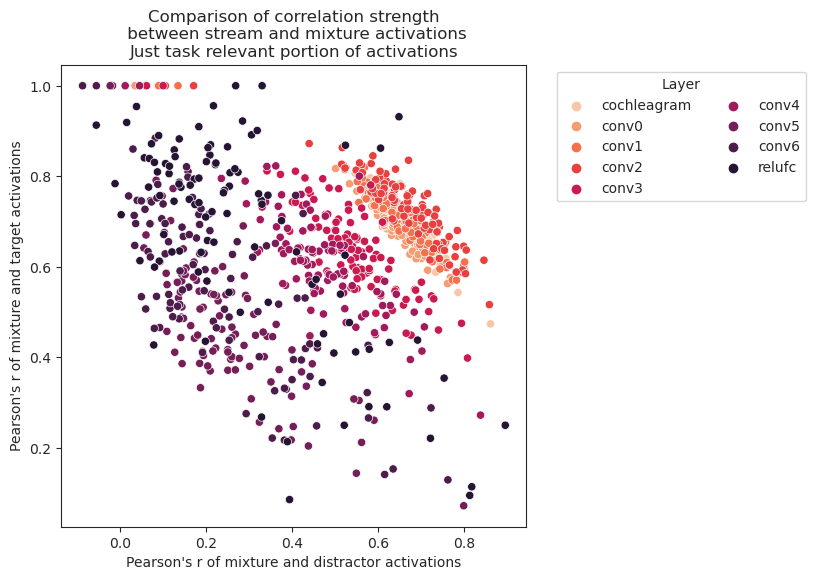

In [42]:

fig, axs = plt.subplots(1, figsize=(6,6))



order = sorted(results.layer.unique())


sns.scatterplot(data=corr_results, x='bg_corrs', y='fg_corrs', hue_order=order,
                hue='layer', palette='rocket_r', ax=axs)

# sns.pointplot(data=results, x='layer', y="Pearson's r", order=order,
#               hue = 'Stream', palette='husl', ax=axs[1],
#              ci=95, n_boot=1000, seed=1)

axs.set_title("Comparison of correlation strength\n between stream and mixture activations\nJust task relevant portion of activations")
axs.set_xlabel("Pearson's r of mixture and distractor activations")
axs.set_ylabel("Pearson's r of mixture and target activations")
axs.legend(title='Layer', ncol=2, frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')
# axs[1].set_ylim(0,1)

# axs[1].set_title("Mixture activations more correlated with\n target activations at later layers")
# axs[1].set_ylabel("Pearson's r")
# rotate x labels for axis 1
# for ax in axs:
#     plt.sca(ax)
#     plt.xticks(rotation=90)

# plt.tight_layout()

Text(0.5, 0.98, 'Full activations')

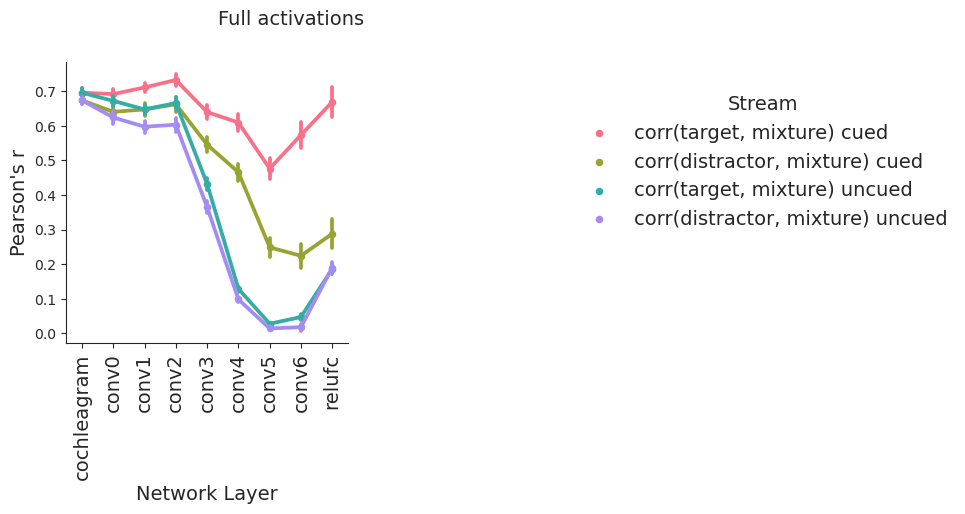

In [43]:
to_plot = results[results['Pearson\'s r'].notna()]
sns.set_style('ticks')

p = sns.catplot(kind='point',data=to_plot, x='layer', y="Pearson's r", order=order,
              hue = 'Stream', palette='husl', 
              height=4, aspect=1, markers='.',
              errorbar=('se', 2), seed=1)
fontsize=14

# plt.title("Speech + Noise Model \nMixture activations more correlated with\n target activations at later layers");
# g.set_axis_labels("", "Prop. Contour Correct")

p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
# set y limit to 0,1
# p.set(ylim=(0,1))

p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
sns.move_legend(p,
                loc="center right", bbox_to_anchor=(1.5, .6),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("Full activations", size=fontsize)


## Same but for cosine similarity

In [ ]:

# load results

# # out_name = out_dir / f"{paths[0].stem}_cos_sim.pkl"


# # results = results['corr_results']
# results = cos_results

# fg_corr_results = {key.replace('_fg', ''): val.squeeze() for key,val in results.items() if '_fg' in key and 'no_cue' not in key}
# bg_corr_results = {key.replace('_bg', ''): val.squeeze() for key,val in results.items() if '_bg' in key and 'no_cue' not in key}

# fg_no_cue_corr_results = {key.replace('_fg_no_cue', ''): val.squeeze() for key,val in results.items() if '_fg_no_cue' in key}
# bg_no_cue_corr_results = {key.replace('_bg_no_cue', ''): val.squeeze() for key,val in results.items() if '_bg_no_cue' in key}

# ## copy over cochleagram results from fg_corr to fg_no_cue becuase these are the same 
# fg_no_cue_corr_results['cochleagram'] = fg_corr_results['cochleagram']
# bg_no_cue_corr_results['cochleagram'] = bg_corr_results['cochleagram']


# dfs = []
# for layer in fg_corr_results.keys():
#     df = pd.DataFrame.from_dict({'fg_cos_sim':fg_corr_results[layer],
#                                  'bg_cos_sim':bg_corr_results[layer],
#                                  'fg_no_cue_cos_sim':fg_no_cue_corr_results[layer],
#                                  'bg_no_cue_cos_sim':bg_no_cue_corr_results[layer],
#                                  'layer': [layer] * len(fg_corr_results[layer])})
            
#     dfs.append(df)
# corr_results = pd.concat(dfs)

# corr_results['layer'] = corr_results['layer'].str.replace('_block_', '')

# results = pd.melt(corr_results, id_vars =['layer'], value_vars=['fg_cos_sim', 'bg_cos_sim', 'fg_no_cue_cos_sim', 'bg_no_cue_cos_sim'], var_name='Stream',
#                             value_name="Cosine similarity")
# results['Stream'].replace('fg_cos_sim','target with cue',inplace=True)
# results['Stream'].replace('bg_cos_sim','distractor with cue',inplace=True)
# results['Stream'].replace('fg_no_cue_cos_sim','target without cue',inplace=True)
# results['Stream'].replace('bg_no_cue_cos_sim','distractor without cue',inplace=True)


Text(0.5, 0.98, '50% co-located in training')

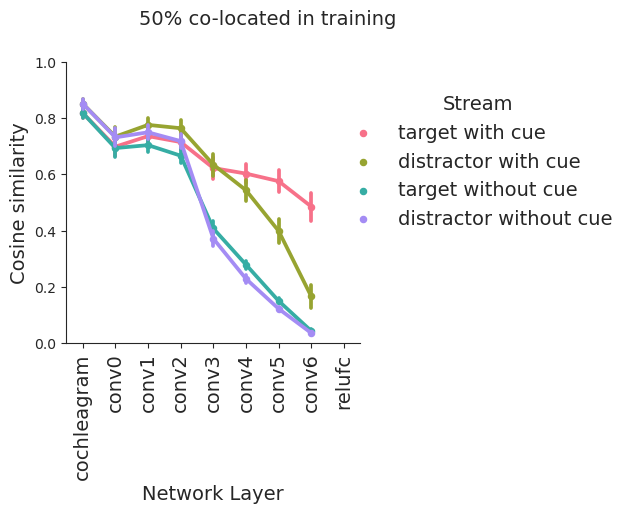

In [71]:
to_plot = results[results['Cosine similarity'].notna()]
sns.set_style('ticks')

p = sns.catplot(kind='point',data=to_plot, x='layer', y="Cosine similarity", order=order,
              hue = 'Stream', palette='husl', 
              height=4, aspect=1, markers='.',
              errorbar=('se', 2), seed=1)
fontsize=14

# plt.title("Speech + Noise Model \nMixture activations more correlated with\n target activations at later layers");
# g.set_axis_labels("", "Prop. Contour Correct")

p.set_axis_labels("Network Layer", "Cosine similarity", size=fontsize)
# set y limit to 0,1
p.set(ylim=(0,1))

p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
sns.move_legend(p,
                loc="center right", bbox_to_anchor=(1.1, .6),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("50% co-located in training", size=fontsize)


### Full activations 

In [20]:
# put results into dataframe
# put into df for easy plotting:

# load results

# # out_name = out_dir / f"{paths[0].stem}_cos_sim.pkl"
# with open("binaural_model_attn_stage_reps/word_task_half_co_loc_v07_model_activations_0dB_w_cues_v3_cos_sim_sanity_check.pkl", 'rb') as f:
with open(out_name, 'rb') as f:
    results = pickle.load(f)

results = results['corr_results']
# results = out_dict['corr_results']

fg_corr_results = {key.replace('_fg', ''): val.squeeze() for key,val in results.items() if '_fg' in key and 'no_cue' not in key}
bg_corr_results = {key.replace('_bg', ''): val.squeeze() for key,val in results.items() if '_bg' in key and 'no_cue' not in key}

fg_no_cue_corr_results = {key.replace('_fg_no_cue', ''): val.squeeze() for key,val in results.items() if '_fg_no_cue' in key}
bg_no_cue_corr_results = {key.replace('_bg_no_cue', ''): val.squeeze() for key,val in results.items() if '_bg_no_cue' in key}

## copy over cochleagram results from fg_corr to fg_no_cue becuase these are the same 
fg_no_cue_corr_results['cochleagram'] = fg_corr_results['cochleagram']
bg_no_cue_corr_results['cochleagram'] = bg_corr_results['cochleagram']


dfs = []
for layer in fg_corr_results.keys():
    df = pd.DataFrame.from_dict({'fg_cos_sim':fg_corr_results[layer],
                                 'bg_cos_sim':bg_corr_results[layer],
                                 'fg_no_cue_cos_sim':fg_no_cue_corr_results[layer],
                                 'bg_no_cue_cos_sim':bg_no_cue_corr_results[layer],
                                 'layer': [layer] * len(fg_corr_results[layer])})
            
    dfs.append(df)
corr_results = pd.concat(dfs)

corr_results['layer'] = corr_results['layer'].str.replace('_block_', '')

results = pd.melt(corr_results, id_vars =['layer'], value_vars=['fg_cos_sim', 'bg_cos_sim', 'fg_no_cue_cos_sim', 'bg_no_cue_cos_sim'], var_name='Stream',
                            value_name="Cosine similarity")
results['Stream'].replace('fg_cos_sim','target with cue',inplace=True)
results['Stream'].replace('bg_cos_sim','distractor with cue',inplace=True)
results['Stream'].replace('fg_no_cue_cos_sim','target without cue',inplace=True)
results['Stream'].replace('bg_no_cue_cos_sim','distractor without cue',inplace=True)


In [21]:
results['layer'].unique()

array(['conv2', 'conv5', 'conv3', 'relufc', 'conv0', 'conv6', 'conv4',
       'cochleagram', 'conv1'], dtype=object)

In [22]:
order = np.sort(results.layer.unique())


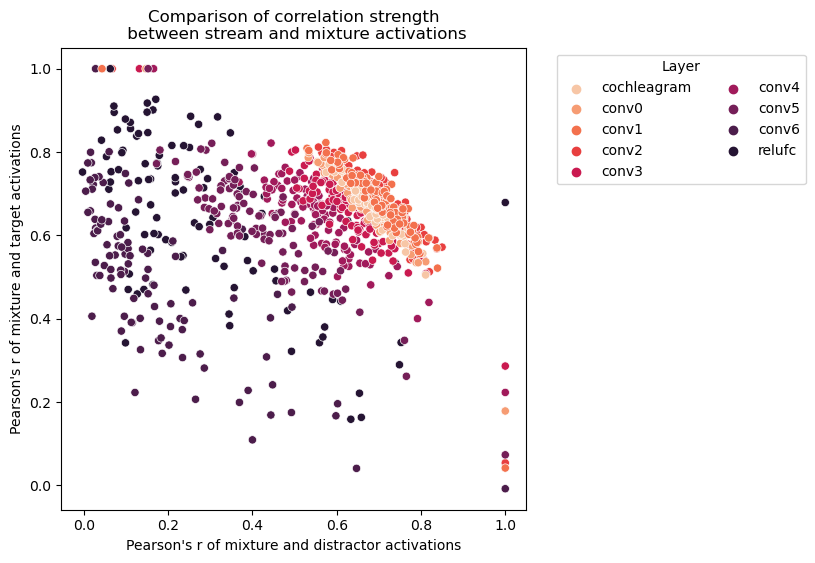

In [79]:

fig, axs = plt.subplots(1, figsize=(6,6))



# order = results.layer.unique()


sns.scatterplot(data=corr_results, x='bg_corrs', y='fg_corrs', hue_order=order,
                hue='layer', palette='rocket_r', ax=axs)

# sns.pointplot(data=results, x='layer', y="Pearson's r", order=order,
#               hue = 'Stream', palette='husl', ax=axs[1],
#              ci=95, n_boot=1000, seed=1)

axs.set_title("Comparison of correlation strength\n between stream and mixture activations")
axs.set_xlabel("Pearson's r of mixture and distractor activations")
axs.set_ylabel("Pearson's r of mixture and target activations")
axs.legend(title='Layer', ncol=2, frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')
# axs[1].set_ylim(0,1)

# axs[1].set_title("Mixture activations more correlated with\n target activations at later layers")
# axs[1].set_ylabel("Pearson's r")
# rotate x labels for axis 1
# for ax in axs:
#     plt.sca(ax)
#     plt.xticks(rotation=90)

# plt.tight_layout()

In [15]:
results[results['Pearson\'s r'].isna()]

,layer,Stream,Pearson's r
80,cochleagram,target,NaN
926,cochleagram,distractor,NaN


Text(0.5, 0.98, '50% co-located in training')

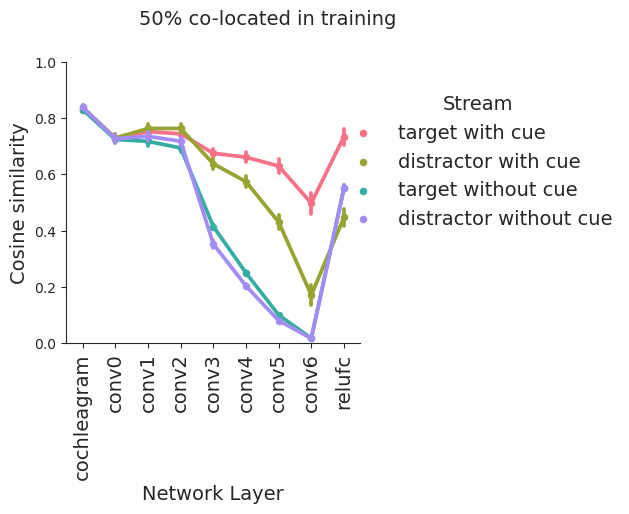

In [ ]:
to_plot = results[results['Cosine similarity'].notna()]
sns.set_style('ticks')

p = sns.catplot(kind='point',data=to_plot, x='layer', y="Cosine similarity", order=order,
              hue = 'Stream', palette='husl', 
              height=4, aspect=1, markers='.',
              errorbar=('se', 2), seed=1)
fontsize=14

# plt.title("Speech + Noise Model \nMixture activations more correlated with\n target activations at later layers");
# g.set_axis_labels("", "Prop. Contour Correct")

p.set_axis_labels("Network Layer", "Cosine similarity", size=fontsize)
# set y limit to 0,1
p.set(ylim=(0,1))

p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
sns.move_legend(p,
                loc="center right", bbox_to_anchor=(1.1, .6),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("50% co-located in training", size=fontsize)


Text(0.5, 0.98, '50% co-located in training')

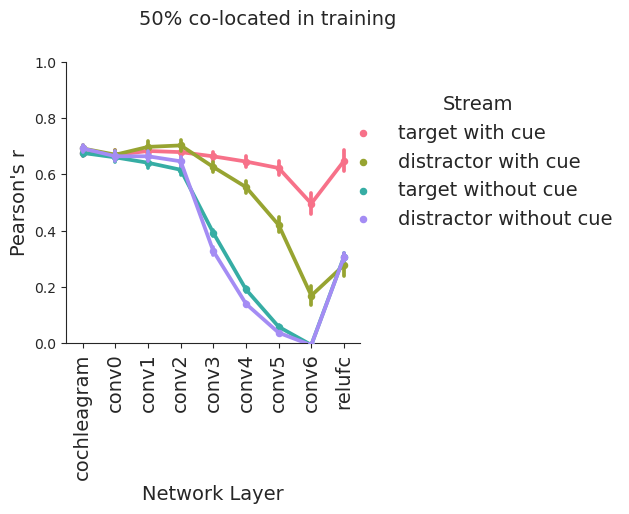

In [81]:
to_plot = results[results['Pearson\'s r'].notna()]
sns.set_style('ticks')

p = sns.catplot(kind='point',data=to_plot, x='layer', y="Pearson's r", order=order,
              hue = 'Stream', palette='husl', 
              height=4, aspect=1, markers='.',
              errorbar=('se', 2), seed=1)
fontsize=14

# plt.title("Speech + Noise Model \nMixture activations more correlated with\n target activations at later layers");
# g.set_axis_labels("", "Prop. Contour Correct")

p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
# set y limit to 0,1
p.set(ylim=(0,1))

p.set_xticklabels(rotation=90, size=fontsize)
# g.set_yticklabels(size=fontsize)

# plt.yscale('log')
sns.move_legend(p,
                loc="center right", bbox_to_anchor=(1.1, .6),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)
p.fig.subplots_adjust(top=.85) # adjust the Figure in

# p.fig.suptitle("Mixture activations more correlated with\n target activations at later layers\n\n50% co-located in training", size=fontsize, y=1.05)
p.fig.suptitle("50% co-located in training", size=fontsize)



: 